## 0. Load Packages

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. 1차 데이터 전처리

In [3]:
df = pd.read_csv('../data/logistics.csv')

In [4]:
df.head()

,fr_orig,dms_orig,dms_dest,fr_dest,fr_inmode,dms_mode,fr_outmode,sctg2,trade_type,dist_band,...,current_value_2022,current_value_2023,current_value_2024,tmiles_2018,tmiles_2019,tmiles_2020,tmiles_2021,tmiles_2022,tmiles_2023,tmiles_2024
0,NaN,11,11,NaN,NaN,1,NaN,1,1,1,...,101.069223,104.272629,115.502844,3.218410,3.351765,3.375547,3.482383,3.502040,3.469055,3.474500
1,NaN,11,19,NaN,NaN,1,NaN,1,1,2,...,764.053625,788.270430,873.167561,48.631191,50.646235,51.005589,52.619906,52.916934,52.418516,52.500796
2,NaN,11,129,NaN,NaN,1,NaN,1,1,3,...,2.695525,2.780960,3.080471,0.450066,0.468714,0.472040,0.486980,0.489729,0.485116,0.485878
3,NaN,11,131,NaN,NaN,1,NaN,1,1,2,...,24.746343,25.530683,28.280351,2.177036,2.267241,2.283328,2.355595,2.368892,2.346580,2.350263
4,NaN,11,139,NaN,NaN,1,NaN,1,1,2,...,10.173100,10.495538,11.625913,1.274964,1.327792,1.337213,1.379536,1.387323,1.374256,1.376413


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2475280 entries, 0 to 2475279
Data columns (total 38 columns):
 #   Column              Dtype  
---  ------              -----  
 0   fr_orig             float64
 1   dms_orig            int64  
 2   dms_dest            int64  
 3   fr_dest             float64
 4   fr_inmode           float64
 5   dms_mode            int64  
 6   fr_outmode          float64
 7   sctg2               int64  
 8   trade_type          int64  
 9   dist_band           int64  
 10  tons_2018           float64
 11  tons_2019           float64
 12  tons_2020           float64
 13  tons_2021           float64
 14  tons_2022           float64
 15  tons_2023           float64
 16  tons_2024           float64
 17  value_2018          float64
 18  value_2019          float64
 19  value_2020          float64
 20  value_2021          float64
 21  value_2022          float64
 22  value_2023          float64
 23  value_2024          float64
 24  current_value_2018  floa

In [6]:
df["sctg2"].value_counts()

sctg2
35    152463
34    143633
24    120669
38    119380
33    119204
40    113139
30    109753
36    108984
37    101776
23     98428
39     92591
31     87757
20     83409
32     81883
7      73871
29     69794
21     67372
26     63637
43     59918
28     57374
3      56828
27     52094
41     47743
4      44625
5      41922
6      40344
13     34022
8      32237
22     29750
19     26760
2      21160
18     19284
1      16497
25     15500
17     12626
14     11797
9      11420
11     10999
12      9507
10      6748
15      5726
16      2656
Name: count, dtype: int64

In [7]:
df.isna().sum()

fr_orig               1469102
dms_orig                    0
dms_dest                    0
fr_dest               1524891
fr_inmode             1469102
dms_mode                    0
fr_outmode            1524891
sctg2                       0
trade_type                  0
dist_band                   0
tons_2018                   0
tons_2019                   0
tons_2020                   0
tons_2021                   0
tons_2022                   0
tons_2023                   0
tons_2024                   0
value_2018                  0
value_2019                  0
value_2020                  0
value_2021                  0
value_2022                  0
value_2023                  0
value_2024                  0
current_value_2018          0
current_value_2019          0
current_value_2020          0
current_value_2021          0
current_value_2022          0
current_value_2023          0
current_value_2024          0
tmiles_2018                 0
tmiles_2019                 0
tmiles_202

- 전체 데이터를 확인했을 때 fr_orig, fr_dest 등 해외 수입/수출 여부에 대해서만 NA가 존재한다.

- 또한, tons, value, current_value, tmiles와 같은 변수들은 0이 기록되어 있을 가능성이 있어 EDA과정에서 0을 어떻게 처리해야 할지 간단하게 분석을 수행하였다.

#### 1.1 주요 지표 0값에 대한 해석 및 처리

In [8]:
# 1. 연도 목록 추출
years = [2018, 2019, 2020, 2021, 2022, 2023, 2024]

# 2. 고정 컬럼
id_cols = [
    "dms_orig", "dms_dest",
    "fr_orig", "fr_dest",
    "dms_mode", "fr_inmode", "fr_outmode",
    "sctg2",
    "trade_type",
    "dist_band"
]

# 3. long 포맷용 데이터 생성
dfs = []

for y in years:
    temp = df[id_cols].copy()
    temp["year"] = y
    temp["tons"] = df[f"tons_{y}"]
    temp["value"] = df.get(f"value_{y}")
    temp["current_value"] = df.get(f"current_value_{y}")
    temp["tmiles"] = df.get(f"tmiles_{y}")
    dfs.append(temp)

df_long = pd.concat(dfs, ignore_index=True)
print(df_long.shape)

(17326960, 15)


In [9]:
df_long.head()

,dms_orig,dms_dest,fr_orig,fr_dest,dms_mode,fr_inmode,fr_outmode,sctg2,trade_type,dist_band,year,tons,value,current_value,tmiles
0,11,11,NaN,NaN,1,NaN,NaN,1,1,1,2018,51.863434,68.594362,66.560261,3.218410
1,11,19,NaN,NaN,1,NaN,NaN,1,1,2,2018,392.072310,518.553218,503.176016,48.631191
2,11,129,NaN,NaN,1,NaN,NaN,1,1,3,2018,1.383202,1.829418,1.775168,0.450066
3,11,131,NaN,NaN,1,NaN,NaN,1,1,2,2018,12.698528,16.795020,16.296980,2.177036
4,11,139,NaN,NaN,1,NaN,NaN,1,1,2,2018,5.220302,6.904350,6.699608,1.274964


In [10]:
# 전체 컬럼 중 음수 데이터 확인
cols = [col for col in df_long.columns] 

print("--- 컬럼별 음수 데이터 개수 ---")
print((df_long[cols] < 0).sum())

--- 컬럼별 음수 데이터 개수 ---
dms_orig         0
dms_dest         0
fr_orig          0
fr_dest          0
dms_mode         0
fr_inmode        0
fr_outmode       0
sctg2            0
trade_type       0
dist_band        0
year             0
tons             0
value            0
current_value    0
tmiles           0
dtype: int64


In [11]:
tons_0 = df_long.loc[(df_long['tons'] == 0),['tons','value','current_value','tmiles']].apply(sum)

print(tons_0)

tons_0_df = df_long.loc[(df_long['tons'] == 0)]
len(tons_0_df)

tons              0.000000
value            30.759039
current_value    35.249362
tmiles            0.001731
dtype: float64


5580580

In [12]:
df_long[df_long["tons"] == 0]

,dms_orig,dms_dest,fr_orig,fr_dest,dms_mode,fr_inmode,fr_outmode,sctg2,trade_type,dist_band,year,tons,value,current_value,tmiles
518714,20,20,801.0,NaN,5,5.0,NaN,1,2,6,2018,0.0,0.0,0.0,0.0
518721,61,121,801.0,NaN,5,5.0,NaN,1,2,8,2018,0.0,0.0,0.0,0.0
518722,61,122,801.0,NaN,5,5.0,NaN,1,2,8,2018,0.0,0.0,0.0,0.0
518723,61,123,801.0,NaN,5,5.0,NaN,1,2,8,2018,0.0,0.0,0.0,0.0
518724,61,124,801.0,NaN,5,5.0,NaN,1,2,8,2018,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17326953,559,20,NaN,808.0,4,NaN,4.0,43,3,8,2024,0.0,0.0,0.0,0.0
17326954,559,64,NaN,808.0,5,NaN,3.0,43,3,8,2024,0.0,0.0,0.0,0.0
17326956,559,151,NaN,808.0,4,NaN,4.0,43,3,8,2024,0.0,0.0,0.0,0.0
17326957,559,171,NaN,808.0,1,NaN,4.0,43,3,2,2024,0.0,0.0,0.0,0.0


음수 데이터는 없고, ton이 0인 경우를 확인했을 때 꽤나 많은 데이터가 포함이 되었다.

In [13]:
tons_0_df['dist_band'].value_counts()

dist_band
8    1115830
6     985003
3     791891
4     736781
5     707630
7     637250
2     427987
1     178208
Name: count, dtype: int64

평균 가중 거리 구간(dist band : sum(거리 * 물동량) / sum(물동량))이 ton이 0임에도 가장 높은 구간에 대부분 포함되었다.

-> 해외 수입/수출이 주를 이루지 않을까? 라고 생각

In [14]:
# 항공 / 트럭 / 기차 / 배 / 메일?소포?
tons_0_df['dms_mode'].value_counts()

dms_mode
4    2260427
1    1205077
2    1029447
5     863147
3     123996
7      93791
6       4382
8        313
Name: count, dtype: int64

동일하게, 항공인 경우가 대부분 -> ton이 0인 데이터들의 구성이 주로 해외 데이터로 구성되어있나?

In [15]:
print(tons_0_df['fr_orig'].notna().sum() + tons_0_df['fr_dest'].notna().sum())

print(len(tons_0_df))

5580580
5580580


ton이 0인 데이터는 모두 해외 수입/수출로 구성되어 있다.

In [16]:
value_0 = df_long.loc[(df_long['value'] == 0),['tons','value','current_value','tmiles']].apply(sum)
print(value_0)

value_0_df = df_long.loc[(df_long['value'] == 0)]
value_0_df.head()

tons             287922.006766
value                 0.000000
current_value         0.000000
tmiles            45904.267380
dtype: float64


,dms_orig,dms_dest,fr_orig,fr_dest,dms_mode,fr_inmode,fr_outmode,sctg2,trade_type,dist_band,year,tons,value,current_value,tmiles
489039,19,61,NaN,NaN,1,NaN,NaN,41,1,8,2018,0.000571,0.0,0.0,0.001178
489041,19,182,NaN,NaN,1,NaN,NaN,41,1,4,2018,0.441184,0.0,0.0,0.234156
489058,19,472,NaN,NaN,1,NaN,NaN,41,1,2,2018,0.678083,0.0,0.0,0.143038
489062,20,20,NaN,NaN,3,NaN,NaN,41,1,4,2018,6.641458,0.0,0.0,3.353718
489065,20,531,NaN,NaN,3,NaN,NaN,41,1,5,2018,60.498798,0.0,0.0,52.843274


In [17]:
# 해외 데이터 길이 / 전체 데이터 길이 (99.97% 가량 해외 데이터)
print( (value_0_df['fr_orig'].notna().sum() + value_0_df['fr_dest'].notna().sum()) / len(value_0_df) )

0.9997991035714363


In [18]:
(value_0_df["fr_orig"].notna() | value_0_df["fr_dest"].notna()).sum() / len(value_0_df)


np.float64(0.9997991035714363)

In [19]:
( value_0_df["fr_orig"].notna() | value_0_df["fr_dest"].notna()).mean()


np.float64(0.9997991035714363)

In [20]:
current_value_0 = df_long.loc[(df_long['current_value'] == 0),['tons','value','current_value','tmiles']].apply(sum)
print(current_value_0)

current_value_0_df = df_long.loc[(df_long['current_value'] == 0)]
current_value_0_df.head()

tons             287922.006766
value                 0.000000
current_value         0.000000
tmiles            45904.267380
dtype: float64


,dms_orig,dms_dest,fr_orig,fr_dest,dms_mode,fr_inmode,fr_outmode,sctg2,trade_type,dist_band,year,tons,value,current_value,tmiles
489039,19,61,NaN,NaN,1,NaN,NaN,41,1,8,2018,0.000571,0.0,0.0,0.001178
489041,19,182,NaN,NaN,1,NaN,NaN,41,1,4,2018,0.441184,0.0,0.0,0.234156
489058,19,472,NaN,NaN,1,NaN,NaN,41,1,2,2018,0.678083,0.0,0.0,0.143038
489062,20,20,NaN,NaN,3,NaN,NaN,41,1,4,2018,6.641458,0.0,0.0,3.353718
489065,20,531,NaN,NaN,3,NaN,NaN,41,1,5,2018,60.498798,0.0,0.0,52.843274


In [21]:
print( (current_value_0_df['fr_orig'].notna().sum() + current_value_0_df['fr_dest'].notna().sum()) / len(current_value_0_df) )

0.9997991035714363


In [22]:
tmiles_0 = df_long.loc[(df_long['tmiles'] == 0),['tons','value','current_value','tmiles']].apply(sum)
print(tmiles_0)

tmiles_0_df = df_long.loc[(df_long['tmiles'] == 0)]
tmiles_0_df.head()

tons             893439.439205
value            300213.334175
current_value    403754.626989
tmiles                0.000000
dtype: float64


,dms_orig,dms_dest,fr_orig,fr_dest,dms_mode,fr_inmode,fr_outmode,sctg2,trade_type,dist_band,year,tons,value,current_value,tmiles
413847,111,111,NaN,NaN,5,NaN,NaN,38,1,1,2018,0.00006,0.028537,0.028919,0.0
435727,111,111,NaN,NaN,5,NaN,NaN,39,1,1,2018,0.00005,0.008678,0.008941,0.0
518714,20,20,801.0,NaN,5,5.0,NaN,1,2,6,2018,0.00000,0.000000,0.000000,0.0
518721,61,121,801.0,NaN,5,5.0,NaN,1,2,8,2018,0.00000,0.000000,0.000000,0.0
518722,61,122,801.0,NaN,5,5.0,NaN,1,2,8,2018,0.00000,0.000000,0.000000,0.0


In [23]:
print( (tmiles_0_df['fr_orig'].notna().sum() + tmiles_0_df['fr_dest'].notna().sum()) / len(tmiles_0_df) )

0.9999974980963193


같은 과정을 value, current_value, tmiles에 대해서 반복했을 때, 거의 대부분의 경우 해외 물류로 구성.

그러면, 분석 프로세스를

1. 데이터를 국내 / 수입 / 수출로 나눈다.

2. 국내 전체 흐름을 Tons, values 분석하고, 주요 생산지/소비지(?)를 파악한다.

* 유의사항 (주로 sum을 기준으로 흐름을 파악할 것이기에, 앞서 소수의 0은 우선 포함하되, value / tons와 같은 파생 변수 생성 시 zero division 에러가 날 수 있음에 유의)

    2.1 도출 결과로 운송 수단이나 다른 추가 분석을 진행할 수 있으면 하고

3. 그 뒤 해외 수입/수출에 대해 분석한다.

    3.1 그 과정에서 0에 대한 처리는 2차 데이터 전처리에서 다시 진행해보자.

### State(주)별 물류 허브 파워 분석

사용 변수  
- dms_orig, dms_dest  
- tons_YYYY, value_YYYY  

파생 변수  
- Outbound Tons (출발 물동량)  
- Inbound Tons (도착 물동량)  
- Hub Index = Outbound + Inbound  
- Value per Ton = value / tons  

분석 질문  
- 가장 많은 화물을 보내는 주는 어디인가?  
- 가장 많은 화물을 받는 주는 어디인가?  
- 물량 대비 가치가 높은 주는 어디인가?  

---
- (1) 연도 컬럼 long-format
        ↓
- (2) Domestic만 필터
        ↓
- (3) State 단위 집계
        ↓
- (4) 파생변수 생성
        ↓
- (5) 랭킹 테이블 생성
        ↓
- (6) 시각화

#### 1.2 기존 데이터 국내 / 수입 / 수출로 분리 및 EDA를 위한 메타 데이터 결합

메타 데이터 결합을 통해 코드를 그에 맞는 이름으로 변환하고, _nm을 붙여 시각화에 용이하게끔 데이터 재구성

In [24]:
# 메타데이터와 결합한 데이터 저장
#df.to_csv('../data/FAF5_join_meta.csv', index = False)

In [25]:
df = pd.read_csv('../data/FAF5_join_meta.csv', low_memory=False)


In [26]:
# memory 900MB -> 속도 느리니까 object를 category로 변환해서 용량 줄이자
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2475280 entries, 0 to 2475279
Data columns (total 52 columns):
 #   Column              Dtype  
---  ------              -----  
 0   fr_orig             float64
 1   dms_orig            int64  
 2   dms_dest            int64  
 3   fr_dest             float64
 4   fr_inmode           float64
 5   dms_mode            int64  
 6   fr_outmode          float64
 7   sctg2               int64  
 8   trade_type          int64  
 9   dist_band           int64  
 10  tons_2018           float64
 11  tons_2019           float64
 12  tons_2020           float64
 13  tons_2021           float64
 14  tons_2022           float64
 15  tons_2023           float64
 16  tons_2024           float64
 17  value_2018          float64
 18  value_2019          float64
 19  value_2020          float64
 20  value_2021          float64
 21  value_2022          float64
 22  value_2023          float64
 23  value_2024          float64
 24  current_value_2018  floa

In [27]:
df.select_dtypes('object').columns

Index(['dms_mode_nm', 'fr_inmode_nm', 'fr_outmode_nm', 'trade_type_nm',
       'dist_band_nm', 'sctg2_name', 'dms_orig_nm', 'dms_dest_nm',
       'state_orig_nm', 'state_dest_nm', 'fr_orig_nm', 'fr_dest_nm'],
      dtype='object')

In [28]:
for col in df.select_dtypes('object').columns:
    df[col] = df[col].astype('category')

In [29]:
# 칼럼 전체가 결측치인 칼럼 제거

# 국내/수입/수출로 분리
dms_df = df.loc[df['trade_type'] == 1]
fr_import = df.loc[df['fr_orig'].notna(),]
fr_export = df.loc[df['fr_dest'].notna(),]

# 필요없는 칼럼(칼럼 전체가 NA인 값) 제거
dms_df = dms_df.dropna(axis = 1, how = 'all')
fr_import = fr_import.dropna(axis = 1, how = 'all')
fr_export = fr_export.dropna(axis = 1, how = 'all')

##### 전체 데이터 요약

In [30]:
# 국내 운송 51만건, 해외 수입 100만건, 해외 수출 95만건
print('미국 국내 운송 건수:', dms_df.shape)
print('미국 해외 수입 건수:', fr_import.shape)
print('미국 해외 수출 건수:', fr_export.shape)

print(len(dms_df) + len(fr_import) + len(fr_export))
print(len(df))

미국 국내 운송 건수: (518713, 44)
미국 해외 수입 건수: (1006178, 48)
미국 해외 수출 건수: (950389, 48)
2475280
2475280


In [31]:
df_clean = df.dropna(axis=1, how='all')
df_clean

,fr_orig,dms_orig,dms_dest,fr_dest,fr_inmode,dms_mode,fr_outmode,sctg2,trade_type,dist_band,...,dist_band_nm,sctg2_name,dms_orig_nm,dms_dest_nm,state_orig,state_dest,state_orig_nm,state_dest_nm,fr_orig_nm,fr_dest_nm
0,NaN,11,11,NaN,NaN,1,NaN,1,1,1,...,Below 100,Live animals/fish,Birmingham AL,Birmingham AL,1,1,Alabama,Alabama,NaN,NaN
1,NaN,11,19,NaN,NaN,1,NaN,1,1,2,...,100 - 249,Live animals/fish,Birmingham AL,Rest of AL,1,1,Alabama,Alabama,NaN,NaN
2,NaN,11,129,NaN,NaN,1,NaN,1,1,3,...,250 - 499,Live animals/fish,Birmingham AL,Rest of FL,1,12,Alabama,Florida,NaN,NaN
3,NaN,11,131,NaN,NaN,1,NaN,1,1,2,...,100 - 249,Live animals/fish,Birmingham AL,Atlanta GA,1,13,Alabama,Georgia,NaN,NaN
4,NaN,11,139,NaN,NaN,1,NaN,1,1,2,...,100 - 249,Live animals/fish,Birmingham AL,Rest of GA,1,13,Alabama,Georgia,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2475275,NaN,559,132,808.0,NaN,5,3.0,43,3,6,...,"1,000 - 1,499",Mixed freight,Rest of WI,Savannah GA,55,13,Wisconsin,Georgia,NaN,SE Asia & Oceania
2475276,NaN,559,151,808.0,NaN,4,4.0,43,3,8,...,"Over 2,000",Mixed freight,Rest of WI,Honolulu HI,55,15,Wisconsin,Hawaii,NaN,SE Asia & Oceania
2475277,NaN,559,171,808.0,NaN,1,4.0,43,3,2,...,100 - 249,Mixed freight,Rest of WI,Chicago IL-IN-WI (IL Part),55,17,Wisconsin,Illinois,NaN,SE Asia & Oceania
2475278,NaN,559,451,808.0,NaN,2,3.0,43,3,6,...,"1,000 - 1,499",Mixed freight,Rest of WI,Charleston SC,55,45,Wisconsin,South Carolina,NaN,SE Asia & Oceania


In [32]:
import pyarrow
import pandas as pd




In [33]:
df = pd.read_parquet("../data/FAF5_join_meta.parquet")

In [34]:
df[['state_orig_nm','state_dest_nm']].head()


,state_orig_nm,state_dest_nm
0,Alabama,Alabama
1,Alabama,Alabama
2,Alabama,Florida
3,Alabama,Georgia
4,Alabama,Georgia


In [35]:
years = [2018, 2019, 2020, 2021, 2022, 2023, 2024]

result = []

for y in years:

    outbound = (
        df.groupby("state_orig_nm",observed=True)[f"tons_{y}"]
          .sum()
          .reset_index()
          .rename(columns={
              "state_orig_nm": "state",
              f"tons_{y}": "outbound_tons"
          })
    )

    inbound = (
        df.groupby("state_dest_nm",observed=True)[f"tons_{y}"]
          .sum()
          .reset_index()
          .rename(columns={
              "state_dest_nm": "state",
              f"tons_{y}": "inbound_tons"
          })
    )

    hub = outbound.merge(inbound, on="state", how="outer")
    hub["year"] = y

    result.append(hub)

hub_long = pd.concat(result, ignore_index=True)

# Hub Index 계산
hub_long["hub_index"] = (
    hub_long["outbound_tons"].fillna(0) +
    hub_long["inbound_tons"].fillna(0)
)

In [36]:
hub_long["hub_index"] = (
    hub_long["outbound_tons"].fillna(0) +
    hub_long["inbound_tons"].fillna(0)
)



In [37]:
display(hub_long.head())

,state,outbound_tons,inbound_tons,year,hub_index
0,Alabama,4.102201e+05,4.194239e+05,2018,8.296440e+05
1,Alaska,5.470390e+04,3.456562e+04,2018,8.926952e+04
2,Arizona,1.898884e+05,2.269534e+05,2018,4.168418e+05
3,Arkansas,2.436029e+05,2.432365e+05,2018,4.868394e+05
4,California,1.229196e+06,1.315320e+06,2018,2.544516e+06


In [38]:
import numpy as np

years = [2018, 2019, 2020, 2021, 2022, 2023, 2024]
result = []

for y in years:
    value_state = (
        df.groupby("state_orig_nm",observed=True)[[f"value_{y}", f"tons_{y}"]]
          .sum()
          .reset_index()
          .rename(columns={
              "state_orig_nm": "state",
              f"value_{y}": "value",
              f"tons_{y}": "tons"
          })
    )

    # value_per_ton 계산 (0으로 나누기 방지)
    value_state["value_per_ton"] = np.where(
        value_state["tons"] > 0,
        value_state["value"] / value_state["tons"],
        np.nan
    )

    value_state["year"] = y
    result.append(value_state)

# 최종 long format 데이터프레임
value_state_long = pd.concat(result, ignore_index=True)

value_state_long



,state,value,tons,value_per_ton,year
0,Alabama,2.883488e+05,4.102201e+05,0.702912,2018
1,Alaska,4.945820e+04,5.470390e+04,0.904107,2018
2,Arizona,2.287623e+05,1.898884e+05,1.204720,2018
3,Arkansas,1.478820e+05,2.436029e+05,0.607062,2018
4,California,2.342587e+06,1.229196e+06,1.905788,2018
...,...,...,...,...,...
352,Washington,4.298103e+05,4.589871e+05,0.936432,2024
353,Washington DC,1.215654e+04,6.357920e+03,1.912031,2024
354,West Virginia,7.103532e+04,2.351663e+05,0.302064,2024
355,Wisconsin,3.500936e+05,4.488725e+05,0.779940,2024


In [39]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append("..")
from src.utils import *



total_value = top_total_value(value_state_long, year=2024, top_n=10)
tons_top   = top_total_tons(value_state_long, year=2024, top_n=10)
hub_top    = top_hub_states(hub_long, year=2024, top_n=10)
density_top = top_value_density(value_state_long, year=2024, top_n=10)


In [40]:
total_value

,state,value,tons,value_per_ton,year
0,Texas,2.489834e+06,3.075369e+06,0.809605,2024
1,California,2.239438e+06,1.129045e+06,1.983479,2024
2,Illinois,1.082245e+06,8.774477e+05,1.233401,2024
3,New York,8.036166e+05,5.110969e+05,1.572337,2024
4,Pennsylvania,7.540166e+05,6.832119e+05,1.103635,2024
5,Michigan,7.164575e+05,5.331832e+05,1.343736,2024
6,Florida,6.792431e+05,7.281122e+05,0.932883,2024
7,Ohio,6.611325e+05,6.816953e+05,0.969836,2024
8,Georgia,6.576662e+05,4.739262e+05,1.387698,2024
9,New Jersey,6.563371e+05,3.488267e+05,1.881556,2024


In [41]:
tons_top

,state,value,tons,value_per_ton,year
0,Texas,2.489834e+06,3.075369e+06,0.809605,2024
1,California,2.239438e+06,1.129045e+06,1.983479,2024
2,Louisiana,3.875290e+05,9.484616e+05,0.408587,2024
3,Illinois,1.082245e+06,8.774477e+05,1.233401,2024
4,Florida,6.792431e+05,7.281122e+05,0.932883,2024
5,Pennsylvania,7.540166e+05,6.832119e+05,1.103635,2024
6,Ohio,6.611325e+05,6.816953e+05,0.969836,2024
7,Minnesota,3.436234e+05,5.631329e+05,0.610199,2024
8,Michigan,7.164575e+05,5.331832e+05,1.343736,2024
9,Indiana,4.910221e+05,5.325366e+05,0.922044,2024


In [42]:
hub_top

,state,outbound_tons,inbound_tons,year,hub_index
0,Texas,3.075369e+06,3.085454e+06,2024,6.160824e+06
1,California,1.129045e+06,1.207599e+06,2024,2.336645e+06
2,Louisiana,9.484616e+05,1.047557e+06,2024,1.996018e+06
3,Illinois,8.774477e+05,9.494560e+05,2024,1.826904e+06
4,Florida,7.281122e+05,8.318821e+05,2024,1.559994e+06
5,Ohio,6.816953e+05,7.224831e+05,2024,1.404178e+06
6,Pennsylvania,6.832119e+05,5.841128e+05,2024,1.267325e+06
7,Minnesota,5.631329e+05,5.627301e+05,2024,1.125863e+06
8,Michigan,5.331832e+05,5.872561e+05,2024,1.120439e+06
9,Indiana,5.325366e+05,5.796583e+05,2024,1.112195e+06


In [43]:
density_top

,state,value,tons,value_per_ton,year
0,California,2.239438e+06,1.129045e+06,1.983479,2024
1,Washington DC,1.215654e+04,6.357920e+03,1.912031,2024
2,New Jersey,6.563371e+05,3.488267e+05,1.881556,2024
3,Massachusetts,3.076809e+05,1.751139e+05,1.757033,2024
4,Rhode Island,5.687071e+04,3.532482e+04,1.609936,2024
5,New York,8.036166e+05,5.110969e+05,1.572337,2024
6,Connecticut,1.838793e+05,1.197600e+05,1.535398,2024
7,Delaware,6.578412e+04,4.341838e+04,1.515122,2024
8,Georgia,6.576662e+05,4.739262e+05,1.387698,2024
9,North Carolina,4.703497e+05,3.468201e+05,1.356178,2024


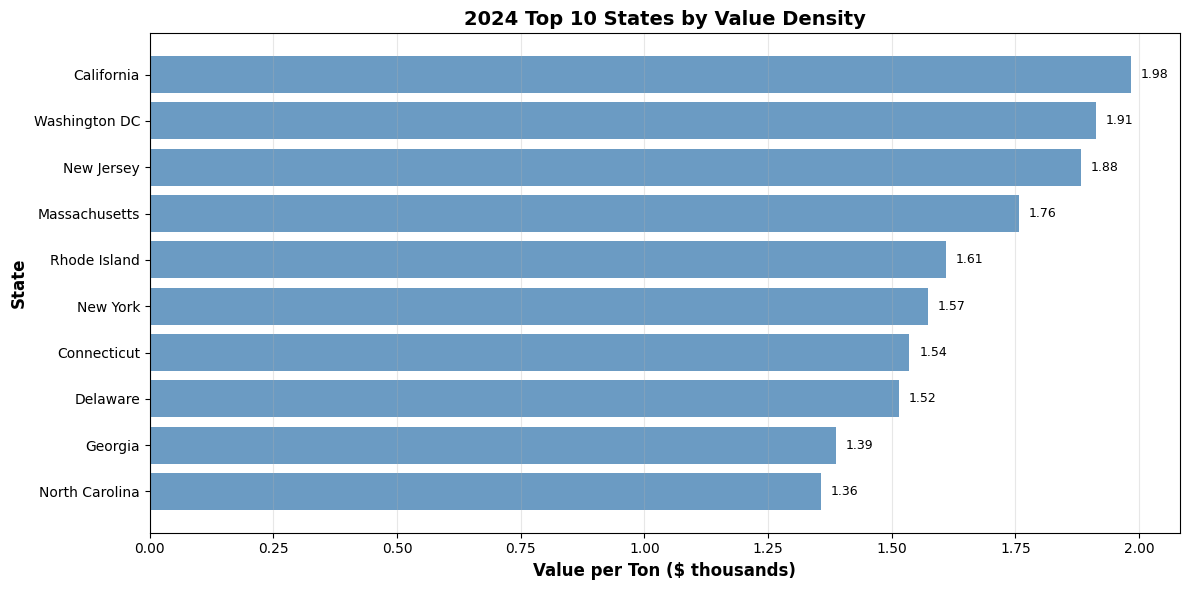

In [44]:
plot_value_per_ton_top10(value_state_long, year=2024)

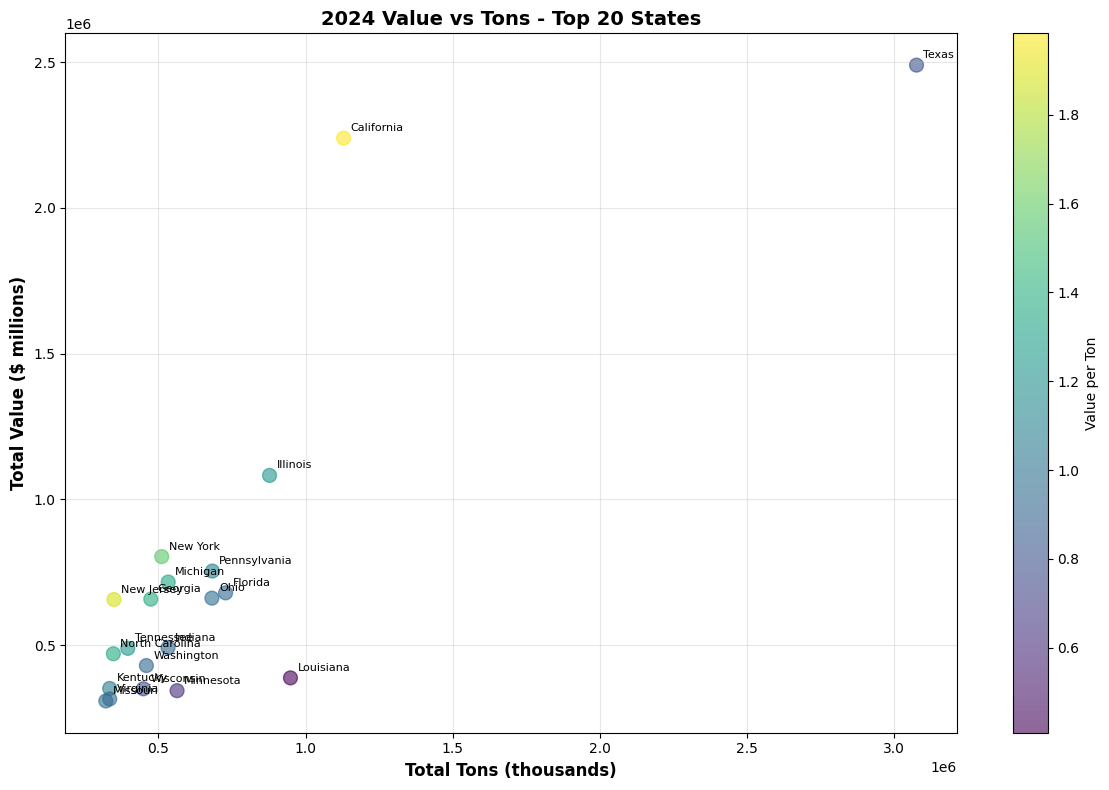

In [45]:
plot_value_vs_tons_scatter(value_state_long, year=2024, top_n=20)

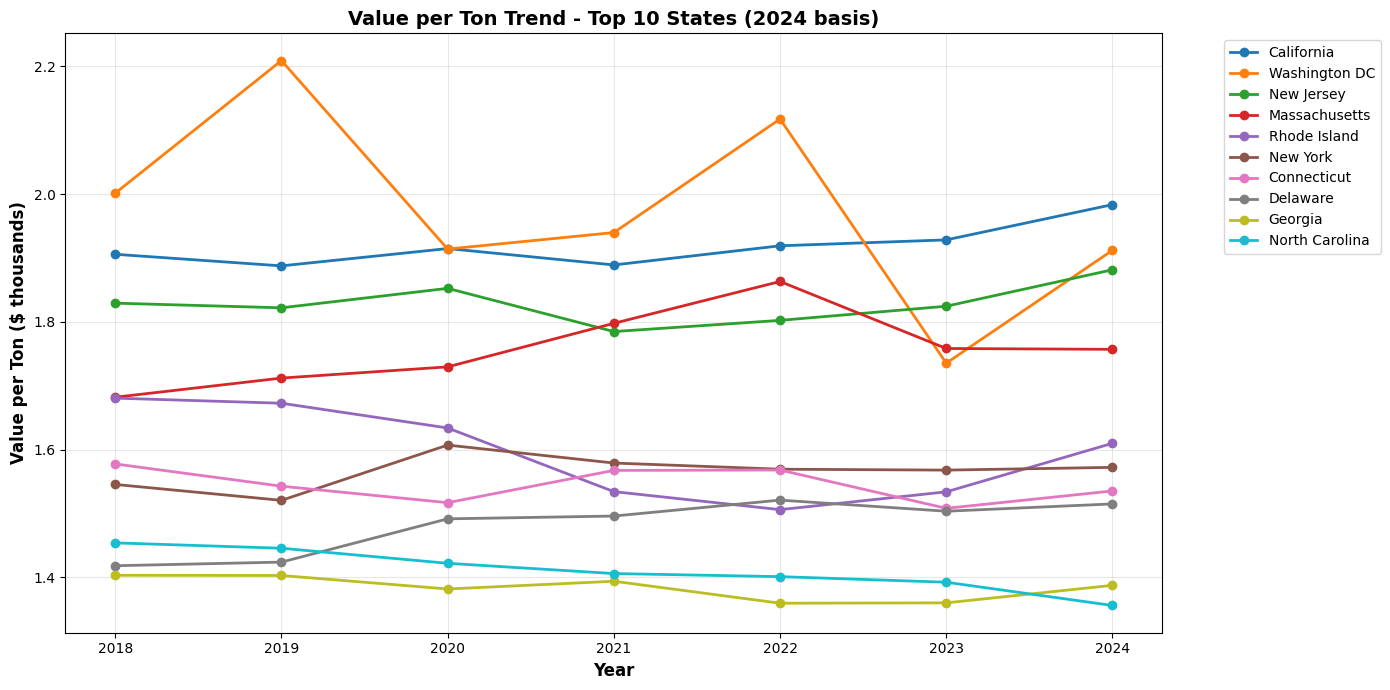

In [46]:
plot_value_per_ton_trend(value_state_long, top_n=10)

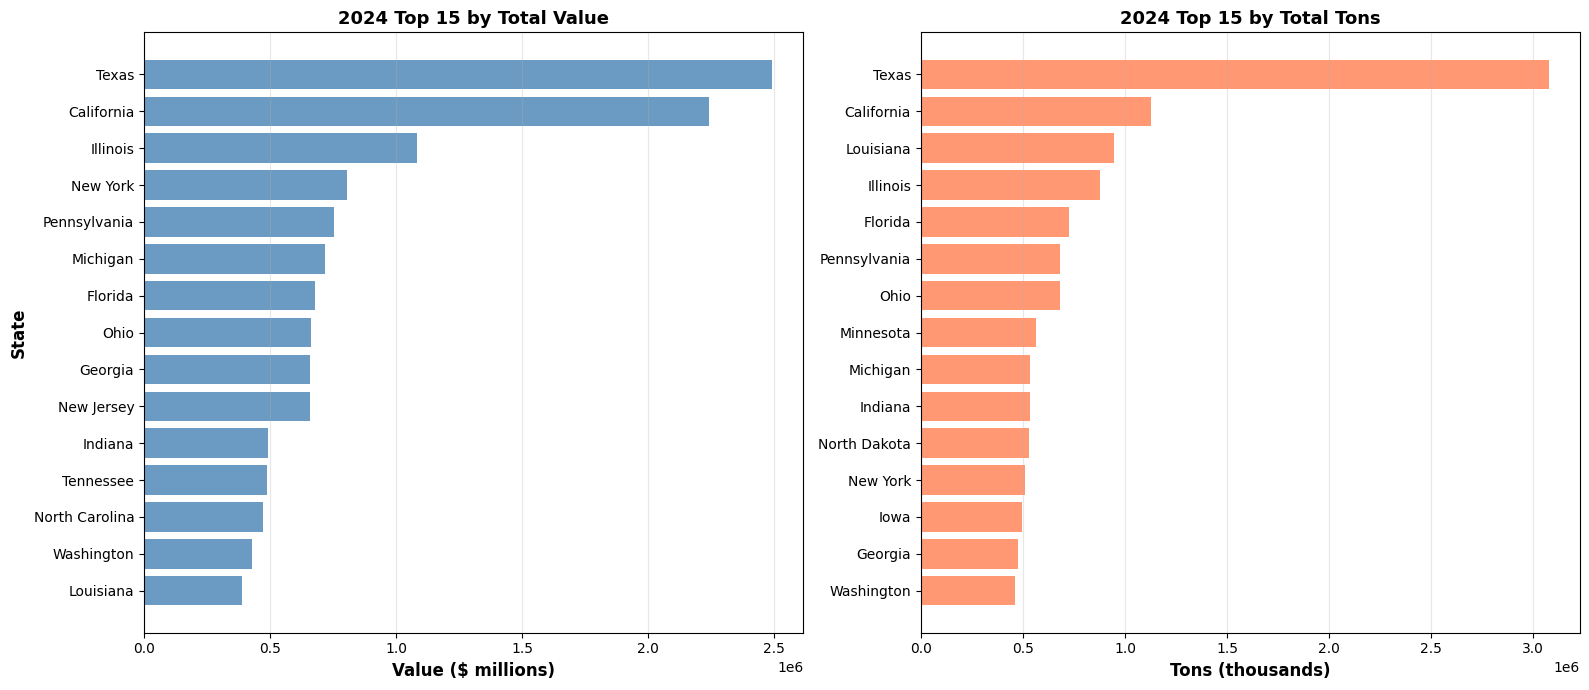

In [47]:
plot_value_ton_comparison(value_state_long, year=2024, top_n=15)

# 코로나 전/후 State(주)별 물류 허브 구조 변화 분석

본 분석은 COVID-19 팬데믹 전후 미국 주(State) 단위 물류 허브 파워가  
어떻게 변화했는지를 비교하여, 물류 구조의 재편 및 허브의 회복력(Resilience)을 평가하는 것을 목표로 한다.

---

## 1. 사용 변수 (Raw Variables)

- `dms_orig` : 출발 주(State)  
- `dms_dest` : 도착 주(State)  
- `tons_YYYY` : 연도별 물동량 (톤)  
- `value_YYYY` : 연도별 화물 가치  

---

## 2. 파생 변수 (Derived Variables)

- **Outbound Tons** : 주별 출발 물동량 합계  
- **Inbound Tons** : 주별 도착 물동량 합계  
- **Hub Index** : Outbound Tons + Inbound Tons  
- **Value per Ton** : value / tons  

---

## 3. 분석 구간 정의

- **Pre-COVID** : 2018–2019 평균  
- **Post-COVID** : 2022–2024 평균  

---

## 4. 추가 파생 변수 (Pre/Post 비교용)

- **Pre Hub Index**  
- **Post Hub Index**  
- **Δ Hub Index** = Post Hub Index − Pre Hub Index  
- **Growth Rate** = Δ Hub Index / Pre Hub Index  

---

## 5. 핵심 분석 질문

- 코로나 이후 **허브 파워가 가장 크게 증가한 주**는 어디인가?  
- 코로나 이후 **허브 파워가 감소한 주**는 어디인가?  
- 고부가가치(Value per Ton) 주는 팬데믹 이후에도 **회복력이 높은가?**  

---

## 6. 분석 파이프라인

### (1) 연도 컬럼 Long-format 변환  
Wide 형식의 `tons_YYYY`, `value_YYYY` →  
`year`, `tons`, `value` 형태로 변환

↓

### (2) 국내, 해외 물류 나눠서 필터링  

↓

### (3) State-Year 단위 집계  

- 출발 기준 → Outbound Tons  
- 도착 기준 → Inbound Tons  

↓

### (4) 파생변수 생성  

- Hub Index  
- Value per Ton  

↓

### (5) Pre/Post 구간별 평균 계산  

- 2018–2019 평균  
- 2022–2024 평균  

↓

### (6) 변화량 계산  

- Δ Hub Index  
- Growth Rate  

↓

### (7) 랭킹 테이블 생성  

- Δ Hub Index Top N (성장 허브)  
- Δ Hub Index Bottom N (쇠퇴 허브)  

↓

### (8) 시각화  

- Pre vs Post Scatter Plot  
- Δ Hub Index Bar Chart  
- Hub Index 연도별 추이 Line Chart  

---

## 7. 최종 산출물

- State별 Pre/Post 비교 테이블  
- 성장 허브 / 쇠퇴 허브 랭킹  
- 핵심 시각화 차트  
- 구조 변화 인사이트 요약


In [1]:
import pandas as pd
import pyarrow
df = pd.read_parquet("../data/FAF5_join_meta.parquet")
df.columns


Index(['fr_orig', 'dms_orig', 'dms_dest', 'fr_dest', 'fr_inmode', 'dms_mode',
       'fr_outmode', 'sctg2', 'trade_type', 'dist_band', 'tons_2018',
       'tons_2019', 'tons_2020', 'tons_2021', 'tons_2022', 'tons_2023',
       'tons_2024', 'value_2018', 'value_2019', 'value_2020', 'value_2021',
       'value_2022', 'value_2023', 'value_2024', 'current_value_2018',
       'current_value_2019', 'current_value_2020', 'current_value_2021',
       'current_value_2022', 'current_value_2023', 'current_value_2024',
       'tmiles_2018', 'tmiles_2019', 'tmiles_2020', 'tmiles_2021',
       'tmiles_2022', 'tmiles_2023', 'tmiles_2024', 'dms_mode_nm',
       'fr_inmode_nm', 'fr_outmode_nm', 'trade_type_nm', 'dist_band_nm',
       'sctg2_name', 'dms_orig_nm', 'dms_dest_nm', 'state_orig', 'state_dest',
       'state_orig_nm', 'state_dest_nm', 'fr_orig_nm', 'fr_dest_nm'],
      dtype='object')

In [2]:
years = [2018, 2019, 2020, 2021, 2022, 2023, 2024]
tons_cols  = [f"tons_{y}" for y in years]
value_cols = [f"value_{y}" for y in years]
id_cols = ["dms_orig", "dms_dest", "fr_orig", "fr_dest", "trade_type"]
 


In [3]:
def wide_to_long_tons_value(df, id_cols, tons_cols, value_cols):

    tons_long = df[id_cols + tons_cols].melt(
        id_vars=id_cols,
        value_vars=tons_cols,
        var_name="year",
        value_name="tons"
    )

    tons_long["year"] = (
        tons_long["year"]
        .str.replace("tons_", "", regex=False)
        .astype(int)
    )

    value_long = df[id_cols + value_cols].melt(
        id_vars=id_cols,
        value_vars=value_cols,
        var_name="year",
        value_name="value"
    )

    value_long["year"] = (
        value_long["year"]
        .str.replace("value_", "", regex=False)
        .astype(int)
    )

    out = tons_long.merge(
        value_long,
        on=id_cols + ["year"],
        how="inner"
    )

    return out


In [4]:
wide_to_long_tons_value(df, id_cols, tons_cols, value_cols).head()

KeyboardInterrupt: 

In [51]:
dms_df     = df.loc[df["trade_type"] == 1].copy()
fr_import  = df.loc[df["fr_orig"].notna()].copy()
fr_export  = df.loc[df["fr_dest"].notna()].copy()


In [52]:
def build_state_year_hub(df_long, orig_col, dest_col):
    # Outbound
    out_t = df_long.groupby(["year", orig_col], as_index=False)["tons"].sum()
    out_v = df_long.groupby(["year", orig_col], as_index=False)["value"].sum()
    out_t = out_t.rename(columns={orig_col: "state", "tons": "out_tons"})
    out_v = out_v.rename(columns={orig_col: "state", "value": "out_value"})

    # Inbound
    in_t = df_long.groupby(["year", dest_col], as_index=False)["tons"].sum()
    in_v = df_long.groupby(["year", dest_col], as_index=False)["value"].sum()
    in_t = in_t.rename(columns={dest_col: "state", "tons": "in_tons"})
    in_v = in_v.rename(columns={dest_col: "state", "value": "in_value"})

    hub = (out_t.merge(in_t, on=["year", "state"], how="outer")
                .merge(out_v, on=["year", "state"], how="outer")
                .merge(in_v, on=["year", "state"], how="outer")
          )

    for c in ["out_tons", "in_tons", "out_value", "in_value"]:
        hub[c] = hub[c].fillna(0)

    hub["hub_index"] = hub["out_tons"] + hub["in_tons"]
    hub["hub_value"] = hub["out_value"] + hub["in_value"]

    hub["value_per_ton"] = np.where(hub["hub_index"] > 0,
                                    hub["hub_value"] / hub["hub_index"],
                                    0.0)
    return hub


In [53]:
def pre_post_compare(hub_state_year, pre_years=(2018,2019), post_years=(2022,2023,2024)):
    pre = hub_state_year[hub_state_year["year"].isin(pre_years)].groupby("state", as_index=False).agg(
        pre_hub_index=("hub_index", "mean"),
        pre_value_per_ton=("value_per_ton", "mean"),
        pre_hub_value=("hub_value", "mean"),
    )

    post = hub_state_year[hub_state_year["year"].isin(post_years)].groupby("state", as_index=False).agg(
        post_hub_index=("hub_index", "mean"),
        post_value_per_ton=("value_per_ton", "mean"),
        post_hub_value=("hub_value", "mean"),
    )

    comp = pre.merge(post, on="state", how="outer").fillna(0)

    comp["delta_hub_index"] = comp["post_hub_index"] - comp["pre_hub_index"]
    comp["growth_rate"] = np.where(comp["pre_hub_index"] > 0,
                                   comp["delta_hub_index"] / comp["pre_hub_index"],
                                   np.nan)  # pre=0이면 성장률 정의 애매 → NaN 권장

    # 회복력/고부가가치 관련 보조지표(
    comp["delta_vpt"] = comp["post_value_per_ton"] - comp["pre_value_per_ton"]
    return comp


In [54]:
#국내
id_cols = ["dms_orig", "dms_dest"]   
dms_long = wide_to_long_tons_value(dms_df, id_cols, tons_cols, value_cols)

hub_dms = build_state_year_hub(dms_long, orig_col="dms_orig", dest_col="dms_dest")
comp_dms = pre_post_compare(hub_dms)

top_growth = comp_dms.sort_values("delta_hub_index", ascending=False).head(10)
bottom_growth = comp_dms.sort_values("delta_hub_index", ascending=True).head(10)


In [55]:
def build_state_year_flow_only(df_long, state_col, flow="in"):
    # flow="in": state_col 기준 inbound 합
    # flow="out": state_col 기준 outbound 합
    grp_cols = ["year", state_col]
    agg = df_long.groupby(grp_cols, as_index=False).agg(
        tons=("tons","sum"),
        value=("value","sum")
    ).rename(columns={state_col:"state"})
    agg["value_per_ton"] = np.where(agg["tons"]>0, agg["value"]/agg["tons"], 0.0)
    return agg


In [56]:
import matplotlib.pyplot as plt

def plot_pre_post_scatter(comp, title="Pre vs Post Hub Index"):
    d = comp.dropna(subset=["growth_rate"]).copy()
    plt.figure()
    plt.scatter(d["pre_hub_index"], d["post_hub_index"])
    plt.xlabel("Pre Hub Index (2018-2019 avg)")
    plt.ylabel("Post Hub Index (2022-2024 avg)")
    plt.title(title)
    plt.show()


In [57]:
def plot_delta_bar(comp, top_n=10, ascending=False, title="Delta Hub Index"):
    d = comp.sort_values("delta_hub_index", ascending=ascending).head(top_n)
    plt.figure()
    plt.bar(d["state"].astype(str), d["delta_hub_index"])
    plt.xticks(rotation=45, ha="right")
    plt.title(title)
    plt.ylabel("Δ Hub Index")
    plt.show()


In [58]:
def plot_hub_trend(hub_state_year, states, title="Hub Index Trend"):
    d = hub_state_year[hub_state_year["state"].isin(states)].copy()
    pivot = d.pivot_table(index="year", columns="state", values="hub_index", aggfunc="sum")
    plt.figure()
    plt.plot(pivot.index, pivot.values)
    plt.title(title)
    plt.xlabel("year")
    plt.ylabel("hub_index")
    plt.show()
